# 05 — EDA Vélo de route

**Objectif** : Explorer les splits vélo du dataset triathlon (Sprint 20km / Olympic 40km / Half 90km / Full 180km)  
pour comprendre la distribution des performances, l'impact de l'âge et du genre, et préparer la modélisation.

**Source** : vladislavboyadzhi/triathlon-results (Kaggle) — 2,96M résultats d'épreuves triathlon 2012-2022  
**Distances vélo** : Sprint=20km | Olympic=40km | Half=90km | Full=180km

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid')
pd.set_option('display.float_format', '{:.2f}'.format)

In [3]:
# Chargement et filtrage des splits vélo
RAW_PATH = '../data/raw/cycling/triathlon_results.csv'

def parse_time(t):
    """Convertit 'H:MM:SS' ou 'MM:SS' en secondes."""
    if pd.isna(t) or t == '0:00' or t == '' or str(t).strip() == '0:00:00':
        return np.nan
    try:
        parts = str(t).strip().split(':')
        if len(parts) == 3:
            return int(parts[0]) * 3600 + int(parts[1]) * 60 + int(parts[2])
        elif len(parts) == 2:
            return int(parts[0]) * 60 + int(parts[1])
    except:
        return np.nan

def age_from_group(group):
    """Extrait l'âge médian depuis le groupe d'âge (ex: M25-29 -> 27)."""
    try:
        nums = ''.join(c if c.isdigit() or c == '-' else ' ' for c in str(group)).strip()
        parts = nums.split('-')
        parts = [p.strip() for p in parts if p.strip().isdigit()]
        if len(parts) == 2:
            return (int(parts[0]) + int(parts[1])) / 2
        elif len(parts) == 1:
            return int(parts[0])
    except:
        return np.nan

# Lecture en chunks pour performance
chunks = []
for chunk in pd.read_csv(RAW_PATH, chunksize=100000):
    # Garder uniquement les épreuves sprint et olympic
    mask = (chunk['event_link'].str.contains('/sprint/|/olympic/|/half/|/full/', na=False))
    sub = chunk[mask].copy()
    sub['bike_sec'] = sub['person_event_cycle_time_text'].apply(parse_time)
    sub['age'] = sub['person_event_group'].apply(age_from_group)
    sub['gender'] = sub['gender'].map({'M': 0, 'F': 1})
    sub['race_format'] = sub['event_link'].str.extract(r'/(sprint|olympic|half|full)/')
    sub = sub[['race_format', 'gender', 'age', 'bike_sec']].dropna()
    chunks.append(sub)

df = pd.concat(chunks, ignore_index=True)
print(f'Lignes chargées : {len(df):,}')
print(df['race_format'].value_counts())

Lignes chargées : 2,672,040
race_format
half       1431289
full        964583
olympic     181692
sprint       94476
Name: count, dtype: int64


In [4]:
# Distances associées
DIST_KM = {'sprint': 20, 'olympic': 40, 'half': 90, 'full': 180}
df['dist_km'] = df['race_format'].map(DIST_KM)
df['speed_kmh'] = df['dist_km'] / (df['bike_sec'] / 3600)

# Filtrer les valeurs aberrantes
df = df[(df['speed_kmh'] >= 10) & (df['speed_kmh'] <= 60)]
df = df[(df['age'] >= 15) & (df['age'] <= 80)]
print(f'Après nettoyage : {len(df):,}')
df.describe()

Après nettoyage : 2,644,069


,gender,age,bike_sec,dist_km,speed_kmh
count,2644069.00,2644069.00,2644069.00,2644069.00,2644069.00
mean,0.22,40.31,14472.82,117.00,29.86
std,0.42,9.90,6783.38,50.31,4.29
min,0.00,15.00,1200.00,20.00,10.03
25%,0.00,32.00,9938.00,90.00,26.94
50%,0.00,42.00,11803.00,90.00,29.88
75%,0.00,47.00,20753.00,180.00,32.72
max,1.00,80.00,52501.00,180.00,60.00


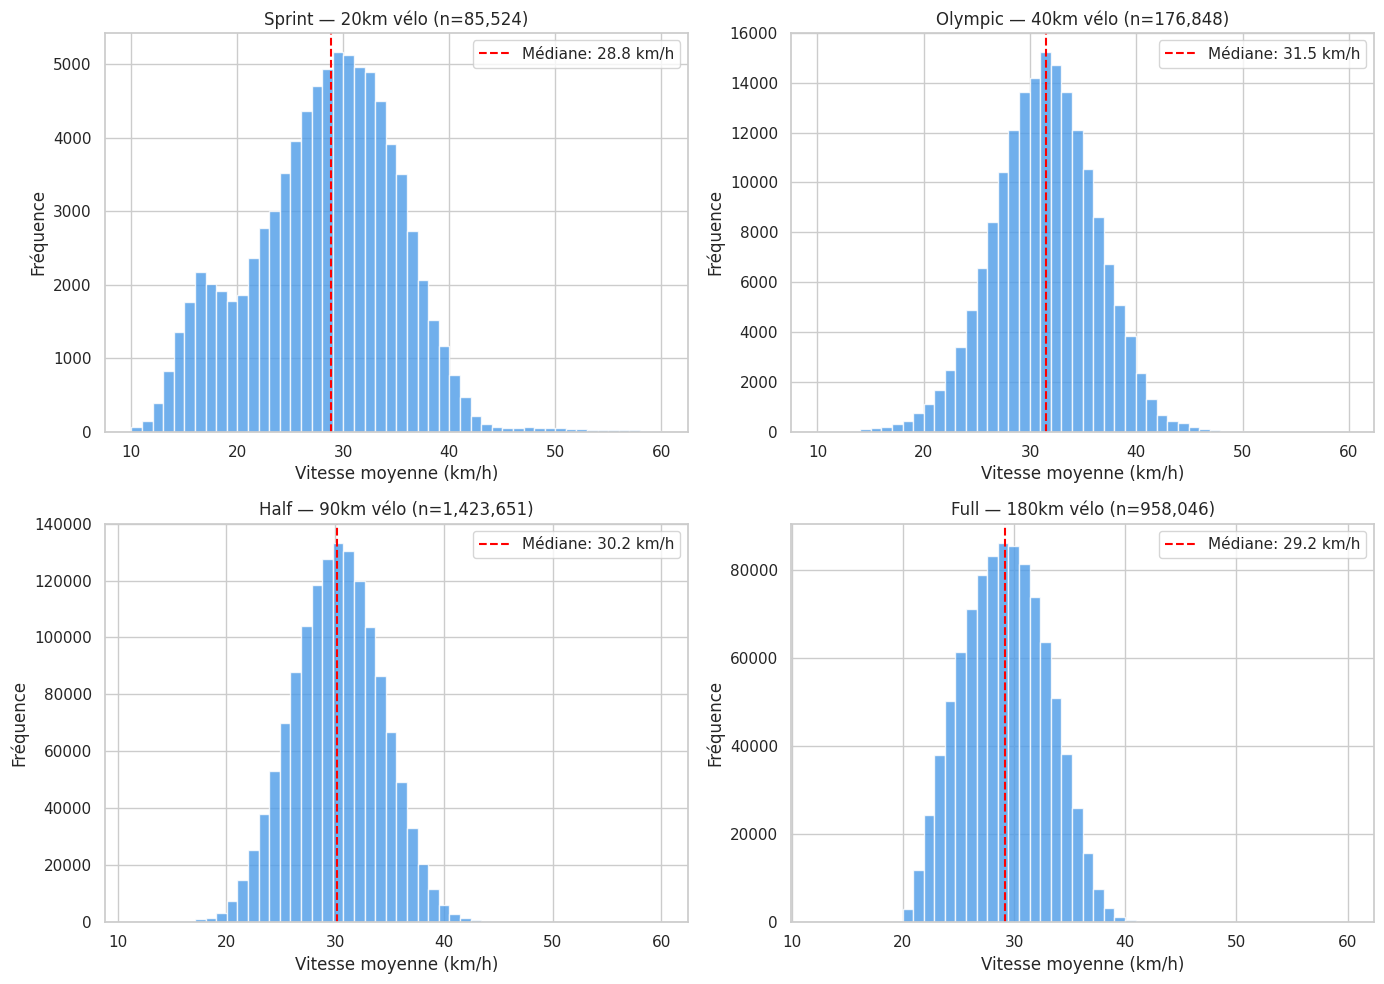

In [5]:
# Distribution des vitesses par format
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
for ax, (fmt, dist) in zip(axes.flatten(), DIST_KM.items()):
    sub = df[df['race_format'] == fmt]
    ax.hist(sub['speed_kmh'], bins=50, color='#4C9BE8', edgecolor='white', alpha=0.8)
    ax.set_title(f'{fmt.capitalize()} — {dist}km vélo (n={len(sub):,})')
    ax.set_xlabel('Vitesse moyenne (km/h)')
    ax.set_ylabel('Fréquence')
    ax.axvline(sub['speed_kmh'].median(), color='red', linestyle='--', label=f'Médiane: {sub["speed_kmh"].median():.1f} km/h')
    ax.legend()
plt.tight_layout()
plt.savefig('../docs/cycling_eda_speed_dist.png', dpi=100, bbox_inches='tight')
plt.show()

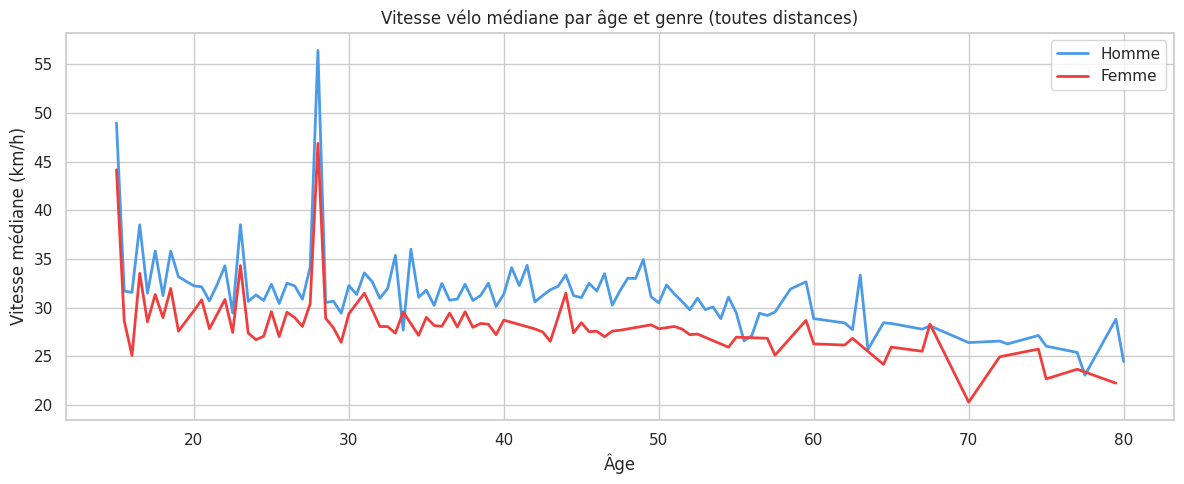

In [6]:
# Vitesse moyenne par âge et genre
fig, ax = plt.subplots(figsize=(12, 5))
for gender_val, label, color in [(0, 'Homme', '#4C9BE8'), (1, 'Femme', '#F03E3E')]:
    sub = df[df['gender'] == gender_val]
    age_speed = sub.groupby('age')['speed_kmh'].median()
    ax.plot(age_speed.index, age_speed.values, label=label, color=color, linewidth=2)
ax.set_xlabel('Âge')
ax.set_ylabel('Vitesse médiane (km/h)')
ax.set_title('Vitesse vélo médiane par âge et genre (toutes distances)')
ax.legend()
plt.tight_layout()
plt.show()

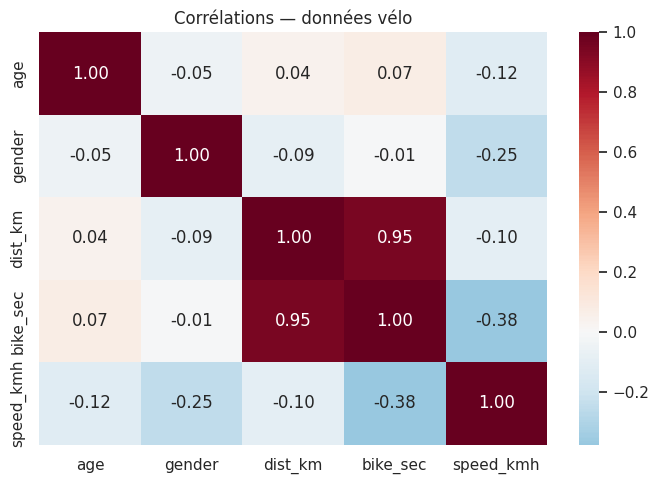


Stats par format de course:
              bike_sec                                                       \
                 count     mean     std      min      25%      50%      75%   
race_format                                                                   
full         958046.00 22566.70 3024.00 10801.00 20281.00 22214.00 24569.00   
half        1423651.00 10944.40 1590.00  5400.00  9825.00 10725.00 11838.00   
olympic      176848.00  4702.00  795.70  2405.00  4160.00  4577.00  5094.00   
sprint        85524.00  2744.10  821.50  1200.00  2178.80  2500.00  3038.00   

                      speed_kmh                                           
                 max      count  mean  std   min   25%   50%   75%   max  
race_format                                                               
full        52501.00  958046.00 29.20 3.90 12.30 26.40 29.20 32.00 60.00  
half        28745.00 1423651.00 30.20 4.20 11.30 27.40 30.20 33.00 60.00  
olympic     14361.00  176848.00 31.40 4.80

In [7]:
# Corrélation features
corr = df[['age', 'gender', 'dist_km', 'bike_sec', 'speed_kmh']].corr()
plt.figure(figsize=(7, 5))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdBu_r', center=0)
plt.title('Corrélations — données vélo')
plt.tight_layout()
plt.show()
print('\nStats par format de course:')
print(df.groupby('race_format')[['bike_sec', 'speed_kmh']].describe().round(1))

In [8]:
# Sauvegarde données nettoyées
df.to_csv('../data/processed/cycling_clean.csv', index=False)
print(f'Sauvegardé : {len(df):,} lignes -> data/processed/cycling_clean.csv')

Sauvegardé : 2,644,069 lignes -> data/processed/cycling_clean.csv
